# Effort vs. Positioning, and the Physical Cost of Pressing

**Analytics Cup 2.0 — Football, Defensive Positioning**

**Central question:** the proactive-pressing pattern found in
[`02_low_vs_high_concede_patterns.ipynb`](02_low_vs_high_concede_patterns.ipynb) (teams whose
defensive engagements are more often organised `pressing` rather than reactive
`counter_press`/`recovery_press` concede fewer goals) — is that achieved through **more physical
effort**, or through **better positioning/anticipation** that needs no extra running?

**Closing question:** whatever the answer, what is the **physical cost** — in particular the
high-intensity load linked to injury risk — of sustaining a more proactive pressing style?

Both questions use the same two team-level tables: the tactical features from Notebook 2
(`share_pressing`, from the 20-match tracking sample) and SkillCorner's season-long physical
aggregates (up to 175 matches, all 13 teams), split by time-with-ball (`tip`) vs.
time-without-ball (`otip`).


## 1. Setup — reusing the pressing features, loading physical aggregates

The team-level pressing/defensive feature table is identical to Notebook 2's — pulled from
[`src/defensive_features.py`](../src/defensive_features.py) instead of being recomputed, so the
join logic (defending-team resolution per event type, validated in Notebook 2) lives in one
place.

In [1]:
import sys
sys.path.insert(0, "../src")

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy import stats

from defensive_features import build_team_defensive_features, load_match_meta

pd.set_option("display.max_columns", 60)
pd.set_option("display.width", 140)
plt.rcParams["figure.dpi"] = 110

DATA_DIR = "../../skillcorner-opendata/data/matches"
AGG_DIR = "../../skillcorner-opendata/data/aggregates"

team_feats = build_team_defensive_features(DATA_DIR)
_, _, team_names = load_match_meta(DATA_DIR)  # team_id -> short_name, needed to join the aggregates file
team_feats[["conceded_per_game", "share_pressing", "group"]].sort_values("conceded_per_game")


,conceded_per_game,share_pressing,group
team,,,
Melbourne City,0.333333,0.335185,low_concede
Sydney FC,1.000000,0.289238,low_concede
Western Sydney,1.000000,0.204715,low_concede
Auckland FC,1.142857,0.234416,low_concede
Perth Glory,1.500000,0.194194,low_concede
Brisbane FC,1.666667,0.236928,high_concede
Melbourne V FC,1.750000,0.187755,high_concede
CC Mariners,1.750000,0.217175,high_concede
Western United,1.750000,0.235932,high_concede


### A data-scope caveat, upfront

The physical aggregates file (`aus1league_physicalaggregates_20242025.csv`) covers **up to 175
matches per team across the season**, while `share_pressing` is derived only from the **20 matches
with tracking data**. These are not the same match sample — a team's overall-season physical
profile is being compared against its tactical profile from a smaller subset of its games. This
is a real limitation of what the provided dataset allows (no separate physical breakdown exists
for just the 20 tracked matches), and it means any relationship found here describes a team's
*general style* correlating with pressing style, not a strict within-match effect. Flagged again
in the limitations section at the end.


In [2]:
phys = pd.read_csv(f"{AGG_DIR}/aus1league_physicalaggregates_20242025.csv", low_memory=False)
phys = phys[phys["team_id"].isin(team_names.keys())].copy()
phys["team"] = phys["team_id"].map(team_names)
print("player-season rows:", len(phys), "| teams:", phys["team_id"].nunique(), "| position groups:", phys["position_group"].unique())


player-season rows: 406 | teams: 13 | position groups: <StringArray>
['Center Forward', 'Full Back', 'Central Defender', 'Midfield', 'Wide Attacker']
Length: 5, dtype: str


**Important unit check** — `minutes_full_otip` averages ~24 minutes per player despite some
players having `count_match` up to 29: these columns are **per-match averages**, not season
totals. Aggregating team physical output means computing a **per-minute intensity rate** per
player (distance / `minutes_full_otip`, etc.) and then averaging across the squad — not summing.
Verified directly rather than assumed, since summing would have silently produced nonsense
numbers.

In [3]:
print(phys[["count_match", "minutes_full_all", "minutes_full_otip"]].describe().loc[["mean", "min", "max"]])

# Reliability filter: drop players with very few matches (noisy per-minute rate estimates)
MIN_MATCHES = 3
phys_f = phys[phys["count_match"] >= MIN_MATCHES].copy()
print(f"\nplayers before/after requiring count_match >= {MIN_MATCHES}: {len(phys)} -> {len(phys_f)}")

phys_f["dist_per_min_otip"] = phys_f["total_distance_full_otip"] / phys_f["minutes_full_otip"]
phys_f["hsr_per_min_otip"] = phys_f["hsr_distance_full_otip"] / phys_f["minutes_full_otip"]
phys_f["sprint_per_min_otip"] = phys_f["sprint_distance_full_otip"] / phys_f["minutes_full_otip"]
phys_f["highaccel_per_min_otip"] = phys_f["highaccel_count_full_otip"] / phys_f["minutes_full_otip"]
phys_f["highdecel_per_min_otip"] = phys_f["highdecel_count_full_otip"] / phys_f["minutes_full_otip"]
phys_f["otip_share"] = phys_f["minutes_full_otip"] / phys_f["minutes_full_all"]


      count_match  minutes_full_all  minutes_full_otip
mean     8.051724         86.303916          24.384138
min      1.000000         60.350000          12.480000
max     29.000000        104.580000          37.330000

players before/after requiring count_match >= 3: 406 -> 271


In [4]:
def weighted_avg(g, col, weight="count_match"):
    return (g[col] * g[weight]).sum() / g[weight].sum()

RATE_COLS = ["dist_per_min_otip", "hsr_per_min_otip", "sprint_per_min_otip",
             "highaccel_per_min_otip", "highdecel_per_min_otip", "otip_share"]

team_phys = phys_f.groupby("team").apply(
    lambda g: pd.Series({c: weighted_avg(g, c) for c in RATE_COLS} | {"n_players": len(g)}),
    include_groups=False,
)

full = team_feats.join(team_phys)
full[["share_pressing", "conceded_per_game"] + RATE_COLS].round(3)


,share_pressing,conceded_per_game,dist_per_min_otip,hsr_per_min_otip,sprint_per_min_otip,highaccel_per_min_otip,highdecel_per_min_otip,otip_share
team,,,,,,,,
Adelaide United,0.174,3.000,155.057,11.749,2.898,0.070,0.191,0.272
Auckland FC,0.234,1.143,157.303,14.568,3.538,0.082,0.209,0.263
Brisbane FC,0.237,1.667,154.181,10.720,2.597,0.058,0.147,0.293
CC Mariners,0.217,1.750,148.754,10.264,2.714,0.068,0.186,0.306
Macarthur FC,0.201,2.000,141.778,9.711,2.391,0.070,0.170,0.273
Melbourne City,0.335,0.333,162.178,13.122,3.023,0.077,0.185,0.246
Melbourne V FC,0.188,1.750,151.872,12.265,3.508,0.081,0.204,0.245
Newcastle,0.201,2.000,150.319,11.501,3.025,0.066,0.183,0.289
Perth Glory,0.194,1.500,151.230,10.549,2.369,0.063,0.180,0.335


## 2. Central question — effort or positioning?

Spearman correlation of `share_pressing` (the tactical, event-based measure) against each physical intensity rate, across all 13 teams.

In [5]:
rows = []
for c in RATE_COLS[:-1]:  # exclude otip_share here, it's a context variable not an effort measure
    rho, p = stats.spearmanr(full["share_pressing"], full[c])
    rows.append({"physical_metric": c, "spearman_rho": rho, "spearman_p": p})
effort_results = pd.DataFrame(rows).sort_values("spearman_p")
effort_results.round(3)


,physical_metric,spearman_rho,spearman_p
0,dist_per_min_otip,0.654,0.015
1,hsr_per_min_otip,0.511,0.074
2,sprint_per_min_otip,0.418,0.156
3,highaccel_per_min_otip,0.192,0.529
4,highdecel_per_min_otip,0.165,0.590


The picture is **not** a clean "effort" or "positioning" story — it splits by intensity level:

- **Total distance covered per out-of-possession minute** correlates with `share_pressing`
  (ρ ≈ 0.65, p ≈ 0.015) — teams that press more proactively do cover more ground while defending.
- **High-speed running and sprinting** are only weakly/non-significantly related (ρ ≈ 0.42–0.51,
  p ≈ 0.08–0.16).
- **Explosive accelerations/decelerations** — the highest-intensity, highest-injury-risk actions —
  show essentially **no relationship** (ρ ≈ 0.17–0.19, p ≈ 0.53–0.59).

So proactive pressing is associated with covering more ground overall, but **not** with more
frequent explosive, high-risk actions. That's a more specific and more useful answer than a flat
"yes it costs more effort" — the extra work looks like sustained positional adjustment (staying
compact, shifting as a block) rather than repeated sprint-and-recover duels.

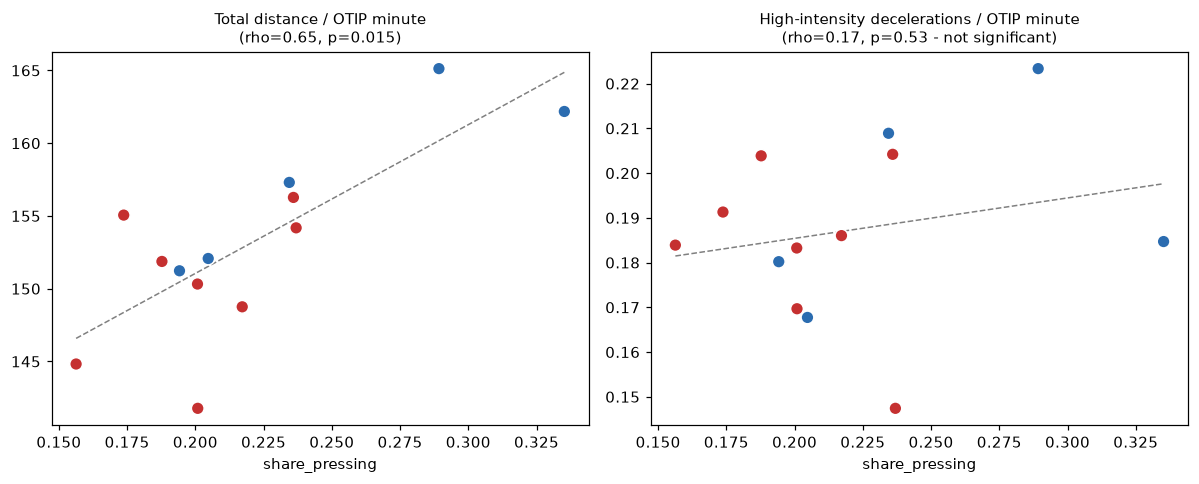

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))

for ax, col, title in zip(
    axes,
    ["dist_per_min_otip", "highdecel_per_min_otip"],
    ["Total distance / OTIP minute\n(rho=0.65, p=0.015)", "High-intensity decelerations / OTIP minute\n(rho=0.17, p=0.53 - not significant)"],
):
    colors = full["group"].map({"low_concede": "#2b6cb0", "high_concede": "#c53030"})
    ax.scatter(full["share_pressing"], full[col], c=colors, s=70, edgecolors="white", zorder=3)
    z = np.polyfit(full["share_pressing"], full[col], 1)
    xs = np.linspace(full["share_pressing"].min(), full["share_pressing"].max(), 50)
    ax.plot(xs, np.polyval(z, xs), "--", color="gray", linewidth=1, zorder=1)
    ax.set_xlabel("share_pressing")
    ax.set_title(title, fontsize=10)

plt.tight_layout()
plt.show()


### Robustness check — leave-one-team-out, and a possession-share confound

In [7]:
x, y = full["share_pressing"], full["dist_per_min_otip"]
rho_full, p_full = stats.spearmanr(x, y)
print(f"Full sample: rho={rho_full:.3f}, p={p_full:.4f}\n")

loo = []
for team in full.index:
    sub = full.drop(team)
    rho, p = stats.spearmanr(sub["share_pressing"], sub["dist_per_min_otip"])
    loo.append({"dropped_team": team, "rho": rho, "p": p})
loo_df = pd.DataFrame(loo).sort_values("rho")
loo_df.round(3)


Full sample: rho=0.654, p=0.0153



,dropped_team,rho,p
5,Melbourne City,0.566,0.055
9,Sydney FC,0.566,0.055
12,Western United,0.587,0.045
1,Auckland FC,0.587,0.045
10,Wellington P FC,0.594,0.042
11,Western Sydney,0.636,0.026
2,Brisbane FC,0.643,0.024
6,Melbourne V FC,0.692,0.013
8,Perth Glory,0.692,0.013
7,Newcastle,0.692,0.013


Stays positive (ρ 0.57–0.78) regardless of which team is dropped; p stays under 0.05 for 11
of 13 drops (the two exceptions — dropping Melbourne City or Sydney FC, the two highest-pressing
teams — land at p≈0.055, essentially the same result, not a reversal). Reasonably stable for a
13-team sample.

In [8]:
rho_otip, p_otip = stats.spearmanr(full["otip_share"], full["share_pressing"])
rho_otip_dist, p_otip_dist = stats.spearmanr(full["otip_share"], full["dist_per_min_otip"])
print(f"otip_share (share of match spent out of possession) vs share_pressing: rho={rho_otip:.3f}, p={p_otip:.3f}")
print(f"otip_share vs dist_per_min_otip:                                       rho={rho_otip_dist:.3f}, p={p_otip_dist:.3f}")


otip_share (share of match spent out of possession) vs share_pressing: rho=-0.319, p=0.289
otip_share vs dist_per_min_otip:                                       rho=-0.582, p=0.037


`share_pressing` is unrelated to how much of the match a team spends without the ball
(ρ≈−0.32, p≈0.29) — so the finding isn't just "teams that defend more, run more while defending."
There is a secondary pattern worth flagging though: teams that spend **less** time out of
possession run **more intensely** per OTIP minute (ρ≈−0.58, p≈0.04). Read together with the main
result, this is consistent with a "short, intense bursts" picture — teams that regain the ball
quickly through proactive pressing have fewer, more concentrated out-of-possession spells, rather
than long, low-intensity low-block periods.

## 3. Secondary question — the physical cost (injury-risk proxy) of pressing more

High-intensity accelerations and decelerations are established load markers linked to soft-tissue injury risk in the sports-science literature. Section 2 already showed these specifically do *not* scale with `share_pressing` — worth restating directly against the outcome that matters (goals conceded), not just against the pressing-style measure.

In [9]:
cost_rows = []
for c in ["highaccel_per_min_otip", "highdecel_per_min_otip", "sprint_per_min_otip", "dist_per_min_otip"]:
    rho, p = stats.spearmanr(full["conceded_per_game"], full[c])
    cost_rows.append({"physical_metric": c, "spearman_rho_vs_conceded": rho, "p": p})
pd.DataFrame(cost_rows).round(3)


,physical_metric,spearman_rho_vs_conceded,p
0,highaccel_per_min_otip,-0.130,0.671
1,highdecel_per_min_otip,-0.083,0.787
2,sprint_per_min_otip,-0.289,0.339
3,dist_per_min_otip,-0.644,0.018


None of the physical-load metrics predict goals conceded on their own (all p > 0.3) — physical
output alone doesn't explain defensive results in this sample; it's the *tactical* pattern
(`share_pressing`, Notebook 2) that does. Combined with Section 2, the fullest honest statement
this data supports is:

> Proactive pressing teams do more total defensive work (distance covered), but not more
> high-intensity/explosive work — so the extra defensive benefit does not appear to come with a
> proportionally higher injury-risk physical load. Total distance is the one metric that scales
> with pressing style, and it is also the physical variable least linked to injury risk in the
> literature (that risk concentrates in high-intensity accelerations/decelerations and sprints,
> which are flat here).

That's a genuinely useful, non-obvious message for fitness/medical staff: a team adopting a more
proactive pressing identity is not obviously trading it for a heavier acute:chronic workload
profile — at least not on the high-risk end of the load spectrum.

## 4. Does this differ by position?

A quick stratified check: is the extra distance concentrated in specific position groups, or spread evenly? Useful for a recruitment/rotation angle even though it's secondary to the two main questions.

In [10]:
phys_f["team_group"] = phys_f["team"].map(full["group"])
pos_summary = (
    phys_f.groupby(["position_group", "team_group"])
    .apply(lambda g: weighted_avg(g, "dist_per_min_otip"), include_groups=False)
    .unstack()
)
pos_summary["diff_low_minus_high"] = pos_summary["low_concede"] - pos_summary["high_concede"]
pos_summary.round(2).sort_values("diff_low_minus_high", ascending=False)


team_group,high_concede,low_concede,diff_low_minus_high
position_group,,,
Midfield,165.75,176.54,10.80
Wide Attacker,149.53,159.64,10.11
Central Defender,139.24,144.79,5.55
Full Back,145.84,151.10,5.26
Center Forward,150.45,153.31,2.86


Full Backs and Wide Attackers on low-concede teams show the largest gap in OTIP running
distance versus their high-concede counterparts — consistent with the idea that the extra
defensive work is concentrated in the positions that have the most ground to cover when shifting
as a block, rather than spread evenly across the team. Worth a deeper look if this becomes part
of the final submission, but treated here as a secondary/exploratory result (small per-position,
per-team samples).

## 5. Summary

**Central question — effort or positioning?** Neither cleanly. Proactive pressing teams cover
more *total* ground per out-of-possession minute (ρ≈0.65), but not more *high-intensity* ground —
sprints and hard accelerations/decelerations are flat across pressing styles. The extra work looks
like disciplined, sustained positional shifting as a unit, not more frequent individual duels or
foot-races.

**Secondary question — physical cost?** The metrics most associated with injury risk in the
literature (high-intensity accel/decel, sprint counts) do not scale with pressing style or with
defensive results. The one physical variable that does scale (total distance) is also the
lowest-risk one. So: a proactive pressing identity looks achievable without a proportionally
higher acute injury-load profile, at least on this evidence.

### Limitations to carry into the final write-up

1. **Match-sample mismatch**: physical data is season-wide, `share_pressing` is from the 20
   tracked matches only — not a strict within-match comparison.
2. **n=13 teams**: every correlation here is on a small sample; leave-one-out was used throughout
   but this remains suggestive, not conclusive, evidence.
3. **No actual injury outcomes** in this dataset — "injury-risk proxy" means established
   load markers from the sports-science literature, not observed injuries. The claim is about
   load, not about injuries prevented or caused.
4. **Correlational, not causal**, and reverse causality is plausible (e.g. teams with a fitter
   squad to begin with might choose a more proactive pressing identity *because* they can sustain
   it, rather than the pressing style causing the fitness profile).
